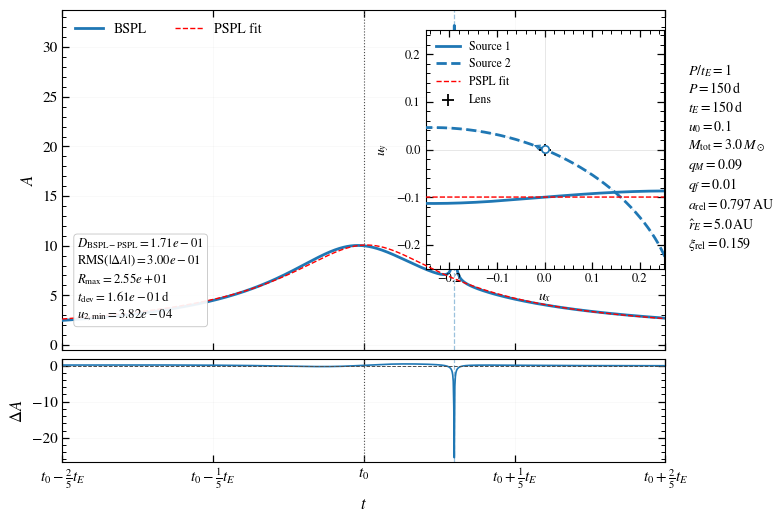


qM               = 0.09000000
D                = 1.71127263e-01
RMS              = 3.00242404e-01
Rmax             = 2.55208908e+01
u2,min           = 3.81936935e-04
A2,max           = 2.61823344e+03
dt(u2,min)/tE   = 1.20062006e-01
best PSPL        = [5.05232943e+01 9.96944406e-02 1.53689950e+02]
PNG              = figures/diagnostics/close_approach_PoverTE1_qf001/close_approach_qM_0p09.png
PDF              = figures/diagnostics/close_approach_PoverTE1_qf001/close_approach_qM_0p09.pdf


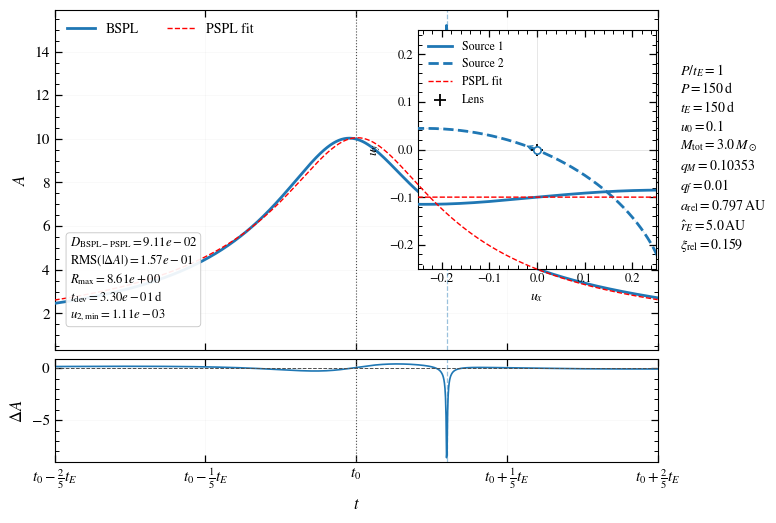


qM               = 0.10353220
D                = 9.10714913e-02
RMS              = 1.57410306e-01
Rmax             = 8.61426285e+00
u2,min           = 1.10582348e-03
A2,max           = 9.04303873e+02
dt(u2,min)/tE   = 1.20062006e-01
best PSPL        = [5.02587537e+01 9.98600991e-02 1.52810516e+02]
PNG              = figures/diagnostics/close_approach_PoverTE1_qf001/close_approach_qM_0p1035322.png
PDF              = figures/diagnostics/close_approach_PoverTE1_qf001/close_approach_qM_0p1035322.pdf


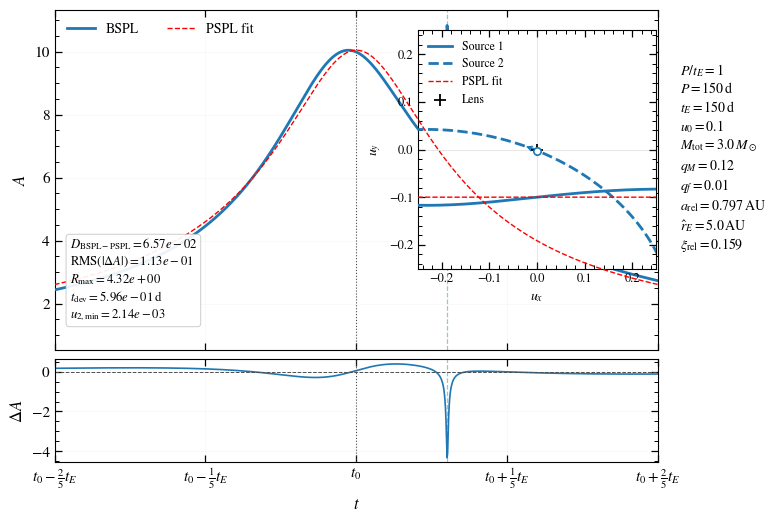


qM               = 0.12000000
D                = 6.57357624e-02
RMS              = 1.13121944e-01
Rmax             = 4.31914789e+00
u2,min           = 2.14047299e-03
A2,max           = 4.67187263e+02
dt(u2,min)/tE   = 1.20762076e-01
best PSPL        = [5.00775471e+01 9.99331840e-02 1.52286684e+02]
PNG              = figures/diagnostics/close_approach_PoverTE1_qf001/close_approach_qM_0p12.png
PDF              = figures/diagnostics/close_approach_PoverTE1_qf001/close_approach_qM_0p12.pdf


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as so

from pathlib import Path
from fractions import Fraction
from matplotlib.ticker import AutoMinorLocator

from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model


# ============================================================
# CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

T0_TRUE = 50.0
U0_TRUE = 0.1
TE_TRUE = 150.0

P_DAYS = 150.0

MTOT_MSUN = 3.0
REHAT_AU = 5.0

QFLUX = 0.01

THETA = 0.0
PHI0 = 0.0
LAMBDA_XI = np.pi / 2.0

FIT_WINDOW_TE = 3.5
DISPLAY_WINDOW_TE = 0.4

N_POINTS = 10000

TRAJ_LIM = 0.25


# Casos que queremos visualizar
QM_CASES = [
    0.09,
    0.1035322,
    0.12,
]


OUTPUT_DIR = Path(
    "figures/diagnostics/"
    "close_approach_PoverTE1_qf001"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# ESTILO
# ============================================================

def set_paper_style():

    plt.rcParams.update({

        "font.size": 11,

        "axes.labelsize": 12,
        "axes.titlesize": 11,

        "legend.fontsize": 10,

        "xtick.labelsize": 11,
        "ytick.labelsize": 11,

        "axes.linewidth": 0.8,

        "xtick.direction": "in",
        "ytick.direction": "in",

        "xtick.top": True,
        "ytick.right": True,

        "xtick.major.size": 5,
        "ytick.major.size": 5,

        "xtick.minor.size": 3,
        "ytick.minor.size": 3,

        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,

        "xtick.minor.width": 0.7,
        "ytick.minor.width": 0.7,

        "savefig.dpi": 600,
        "savefig.bbox": "tight",

        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
    })


# ============================================================
# EVENTO
# ============================================================

def build_sim_event(
    t,
):

    ev = event.Event()

    ev.name = "Simulated"

    ev.ra = 170.0
    ev.dec = -70.0

    lc = np.c_[

        t,

        np.full_like(
            t,
            19.0,
        ),

        np.full_like(
            t,
            1e-9,
        ),
    ]

    tel = telescopes.Telescope(

        name="Simulation",

        camera_filter="G",

        lightcurve=lc.astype(
            float
        ),

        lightcurve_names=[
            "time",
            "mag",
            "err_mag",
        ],

        lightcurve_units=[
            "JD",
            "mag",
            "mag",
        ],

        location="Earth",
    )

    ev.telescopes.append(
        tel
    )

    return ev


# ============================================================
# KEPLER
#
# xi_rel = a_rel / rEhat
# ============================================================

def compute_xi_rel(
    P_days,
    Mtot_Msun,
    rEhat_AU,
):

    P_yr = (
        P_days
        / 365.25
    )

    a_rel_AU = (
        Mtot_Msun
        * P_yr**2
    )**(
        1.0 / 3.0
    )

    xi_rel = (
        a_rel_AU
        / rEhat_AU
    )

    return (
        xi_rel,
        a_rel_AU,
    )


# ============================================================
# MAGNIFICACIÓN PSPL DESDE u
# ============================================================

def pspl_A_from_u(
    u,
):

    u = np.asarray(
        u,
        dtype=float,
    )

    u_safe = np.maximum(
        u,
        np.finfo(float).tiny,
    )

    return (
        (
            u_safe**2
            + 2.0
        )
        /
        (
            u_safe
            * np.sqrt(
                u_safe**2
                + 4.0
            )
        )
    )


# ============================================================
# MODELO BSPL
# ============================================================

def build_bspl_state(
    t,
    q_mass,
):

    xi_rel, a_rel_AU = (
        compute_xi_rel(

            P_days=P_DAYS,

            Mtot_Msun=MTOT_MSUN,

            rEhat_AU=REHAT_AU,
        )
    )

    omega = (
        2.0
        * np.pi
        / P_DAYS
    )

    xi_para = (
        xi_rel
        * np.cos(
            THETA
        )
    )

    xi_perp = (
        xi_rel
        * np.sin(
            THETA
        )
    )


    ev = build_sim_event(
        t
    )


    model = PSPL_model.PSPLmodel(

        ev,

        parallax=[
            "None",
            0.0,
        ],

        double_source=[
            "Circular",
            T0_TRUE,
        ],
    )

    model.define_model_parameters()


    # Los flujos son irrelevantes para el ajuste intrínseco
    # en magnificación, pero pyLIMA espera estos parámetros.
    fs = 1.0
    ftotal = 1.0


    params = [

        T0_TRUE,

        U0_TRUE,

        TE_TRUE,

        xi_para,

        xi_perp,

        omega,

        PHI0,

        LAMBDA_XI,

        q_mass,

        QFLUX,

        fs,

        ftotal,
    ]


    py_params = (
        model.compute_pyLIMA_parameters(
            params
        )
    )


    # pyLIMA devuelve la suma ponderada por los flujos.
    # Dividimos por 1+qf para obtener la magnificación
    # normalizada de la fuente binaria.
    A_bspl = (

        model.model_magnification(

            ev.telescopes[0],

            py_params,
        )

        /
        (
            1.0
            + QFLUX
        )
    )


    trajectories = (
        model.sources_trajectory(

            ev.telescopes[0],

            py_params,

            data_type="photometry",
        )
    )


    (
        source1_x,
        source1_y,

        source2_x,
        source2_y,

        _,
        _,

    ) = trajectories


    source1_x = np.asarray(
        source1_x,
        dtype=float,
    )

    source1_y = np.asarray(
        source1_y,
        dtype=float,
    )

    source2_x = np.asarray(
        source2_x,
        dtype=float,
    )

    source2_y = np.asarray(
        source2_y,
        dtype=float,
    )


    u1 = np.hypot(
        source1_x,
        source1_y,
    )

    u2 = np.hypot(
        source2_x,
        source2_y,
    )


    i1 = int(
        np.nanargmin(
            u1
        )
    )

    i2 = int(
        np.nanargmin(
            u2
        )
    )


    return dict(

        event=ev,

        model=model,

        py_params=py_params,

        A=np.asarray(
            A_bspl,
            dtype=float,
        ),

        source1_x=source1_x,
        source1_y=source1_y,

        source2_x=source2_x,
        source2_y=source2_y,

        u1=u1,
        u2=u2,

        i1_min=i1,
        i2_min=i2,

        u1_min=float(
            u1[i1]
        ),

        u2_min=float(
            u2[i2]
        ),

        t_u1_min=float(
            t[i1]
        ),

        t_u2_min=float(
            t[i2]
        ),

        A1max=float(
            np.nanmax(
                pspl_A_from_u(
                    u1
                )
            )
        ),

        A2max=float(
            np.nanmax(
                pspl_A_from_u(
                    u2
                )
            )
        ),

        xi_rel=xi_rel,

        a_rel_AU=a_rel_AU,

        fs=fs,
        ftotal=ftotal,
    )


# ============================================================
# OBJETIVO PSPL
# ============================================================

def pspl_objective(
    fit_params,
    model,
    A_truth,
):

    fit_params = np.asarray(
        fit_params,
        dtype=float,
    )

    full_params = np.concatenate([

        fit_params,

        [
            1.0,
            1.0,
        ],
    ])


    py_params = (
        model.compute_pyLIMA_parameters(
            full_params
        )
    )


    A_model = (
        model.model_magnification(

            model.event.telescopes[0],

            py_params,
        )
    )


    residual = (
        A_truth
        - A_model
    )


    t = np.asarray(
        model.event.telescopes[
            0
        ].lightcurve[
            "time"
        ],
        dtype=float,
    )


    return float(
        np.trapezoid(
            residual**2,
            x=t,
        )
    )


# ============================================================
# FIT PSPL
# ============================================================

def fit_pspl(
    ev,
    A_truth,
):

    model = PSPL_model.PSPLmodel(

        ev,

        parallax=[
            "None",
            0.0,
        ],

        double_source=[
            "None",
            0.0,
        ],
    )

    model.define_model_parameters()


    x0 = np.array(
        [
            T0_TRUE,
            U0_TRUE,
            TE_TRUE,
        ],
        dtype=float,
    )


    result = so.minimize(

        pspl_objective,

        x0=x0,

        args=(
            model,
            A_truth,
        ),

        method="Nelder-Mead",

        options=dict(

            maxiter=20000,

            xatol=1e-10,

            fatol=1e-12,
        ),
    )


    if not result.success:

        raise RuntimeError(
            result.message
        )


    best = np.asarray(
        result.x,
        dtype=float,
    )


    full_params = np.concatenate([

        best,

        [
            1.0,
            1.0,
        ],
    ])


    py_best = (
        model.compute_pyLIMA_parameters(
            full_params
        )
    )


    A_fit = (
        model.model_magnification(

            ev.telescopes[0],

            py_best,
        )
    )


    trajectories = (
        model.sources_trajectory(

            ev.telescopes[0],

            py_best,

            data_type="photometry",
        )
    )


    fit_x = np.asarray(
        trajectories[0],
        dtype=float,
    )

    fit_y = np.asarray(
        trajectories[1],
        dtype=float,
    )


    return dict(

        best=best,

        A_fit=np.asarray(
            A_fit,
            dtype=float,
        ),

        x=fit_x,
        y=fit_y,
    )


# ============================================================
# t_dev
# ============================================================

def measure_tdev(
    t,
    residual,
):

    t = np.asarray(
        t,
        dtype=float,
    )

    y = np.abs(
        np.asarray(
            residual,
            dtype=float,
        )
    )


    i_max = int(
        np.nanargmax(
            y
        )
    )


    Rmax = float(
        y[
            i_max
        ]
    )


    if (
        not np.isfinite(
            Rmax
        )
        or Rmax <= 0.0
    ):

        return dict(

            Rmax=Rmax,

            tdev=0.0,

            t_left=t[i_max],

            t_right=t[i_max],
        )


    half = (
        0.5
        * Rmax
    )


    # --------------------------------------------------------
    # Left
    # --------------------------------------------------------

    i_left = (
        i_max
    )


    while (
        i_left > 0
        and
        y[
            i_left - 1
        ] >= half
    ):

        i_left -= 1


    if i_left == 0:

        t_left = (
            t[0]
        )


    else:

        x0 = t[
            i_left - 1
        ]

        x1 = t[
            i_left
        ]

        y0 = y[
            i_left - 1
        ]

        y1 = y[
            i_left
        ]


        t_left = (

            x0

            +

            (
                half
                - y0
            )

            *
            (
                x1
                - x0
            )

            /
            (
                y1
                - y0
            )
        )


    # --------------------------------------------------------
    # Right
    # --------------------------------------------------------

    i_right = (
        i_max
    )


    while (
        i_right < len(y) - 1
        and
        y[
            i_right + 1
        ] >= half
    ):

        i_right += 1


    if i_right == len(y) - 1:

        t_right = (
            t[-1]
        )


    else:

        x0 = t[
            i_right
        ]

        x1 = t[
            i_right + 1
        ]

        y0 = y[
            i_right
        ]

        y1 = y[
            i_right + 1
        ]


        t_right = (

            x0

            +

            (
                half
                - y0
            )

            *
            (
                x1
                - x0
            )

            /
            (
                y1
                - y0
            )
        )


    return dict(

        Rmax=Rmax,

        tdev=float(
            t_right
            - t_left
        ),

        t_left=float(
            t_left
        ),

        t_right=float(
            t_right
        ),
    )


# ============================================================
# COMPUTE CASE
# ============================================================

def compute_case(
    q_mass,
):

    t = np.linspace(

        T0_TRUE
        - FIT_WINDOW_TE
        * TE_TRUE,

        T0_TRUE
        + FIT_WINDOW_TE
        * TE_TRUE,

        N_POINTS,
    )


    bspl = build_bspl_state(

        t=t,

        q_mass=q_mass,
    )


    fit = fit_pspl(

        bspl[
            "event"
        ],

        bspl[
            "A"
        ],
    )


    residual = (

        fit[
            "A_fit"
        ]

        - bspl[
            "A"
        ]
    )


    numerator = np.trapezoid(

        residual**2,

        x=t,
    )


    denominator = np.trapezoid(

        (
            bspl[
                "A"
            ]
            - 1.0
        )**2,

        x=t,
    )


    D = np.sqrt(
        numerator
        / denominator
    )


    RMS = np.sqrt(
        np.mean(
            residual**2
        )
    )


    dev = measure_tdev(

        t,

        residual,
    )


    return dict(

        t=t,

        q_mass=q_mass,

        bspl=bspl,

        fit=fit,

        residual=residual,

        D=float(
            D
        ),

        RMS=float(
            RMS
        ),

        Rmax=float(
            np.max(
                np.abs(
                    residual
                )
            )
        ),

        tdev=float(
            dev[
                "tdev"
            ]
        ),
    )


# ============================================================
# FLECHAS
# ============================================================

def add_direction_arrow(
    ax,
    x,
    y,
    color,
    index,
):

    if (
        index <= 0
        or
        index >= len(x) - 1
    ):

        return


    dx = (
        x[
            index + 1
        ]
        - x[
            index - 1
        ]
    )

    dy = (
        y[
            index + 1
        ]
        - y[
            index - 1
        ]
    )


    norm = np.hypot(
        dx,
        dy,
    )


    if norm == 0.0:

        return


    scale = 0.03


    ax.annotate(

        "",

        xy=(

            x[index]
            + scale
            * dx
            / norm,

            y[index]
            + scale
            * dy
            / norm,
        ),

        xytext=(

            x[index],

            y[index],
        ),

        arrowprops=dict(

            arrowstyle="->",

            color=color,

            lw=0.8,

            mutation_scale=9,
        ),
    )


# ============================================================
# TICKS TEMPORALES
# ============================================================

def offset_label(
    value,
):

    if np.isclose(
        value,
        0.0,
    ):

        return r"$t_0$"


    sign = (
        "+"
        if value > 0
        else "-"
    )


    fraction = Fraction(
        abs(
            float(
                value
            )
        )
    ).limit_denominator(
        10
    )


    num = (
        fraction.numerator
    )

    den = (
        fraction.denominator
    )


    if den == 1:

        if num == 1:

            term = (
                r"t_E"
            )

        else:

            term = (
                rf"{num}t_E"
            )


    else:

        if num == 1:

            term = (
                rf"\frac{{1}}{{{den}}}t_E"
            )

        else:

            term = (
                rf"\frac{{{num}}}{{{den}}}t_E"
            )


    return (
        rf"$t_0{sign}{term}$"
    )


def set_time_ticks(
    ax,
):

    offsets = np.array(
        [
            -0.4,
            -0.2,
            0.0,
            0.2,
            0.4,
        ]
    )


    ticks = (

        T0_TRUE

        + offsets
        * TE_TRUE
    )


    ax.set_xticks(
        ticks
    )


    ax.set_xticklabels(
        [
            offset_label(
                value
            )
            for value
            in offsets
        ]
    )


# ============================================================
# PLOT DE UN CASO
# ============================================================

def plot_case(
    q_mass,
):

    set_paper_style()


    out = compute_case(
        q_mass
    )


    t = out[
        "t"
    ]


    A = out[
        "bspl"
    ][
        "A"
    ]


    A_fit = out[
        "fit"
    ][
        "A_fit"
    ]


    residual = out[
        "residual"
    ]


    s1x = out[
        "bspl"
    ][
        "source1_x"
    ]

    s1y = out[
        "bspl"
    ][
        "source1_y"
    ]


    s2x = out[
        "bspl"
    ][
        "source2_x"
    ]

    s2y = out[
        "bspl"
    ][
        "source2_y"
    ]


    fit_x = out[
        "fit"
    ][
        "x"
    ]

    fit_y = out[
        "fit"
    ][
        "y"
    ]


    # ========================================================
    # Sólo resaltamos en el inset la parte correspondiente
    # a la ventana temporal visible.
    # ========================================================

    visible = (

        np.abs(
            (
                t
                - T0_TRUE
            )
            / TE_TRUE
        )

        <= DISPLAY_WINDOW_TE
    )


    # ========================================================
    # FIGURA
    # ========================================================

    fig = plt.figure(

        figsize=(
            9.0,
            5.8,
        )
    )


    gs = fig.add_gridspec(

        2,
        1,

        height_ratios=[
            3.3,
            1.0,
        ],

        hspace=0.04,
    )


    axA = fig.add_subplot(
        gs[
            0,
            0
        ]
    )


    axR = fig.add_subplot(

        gs[
            1,
            0
        ],

        sharex=axA,
    )


    fig.subplots_adjust(

        left=0.10,

        right=0.77,

        bottom=0.13,

        top=0.91,
    )


    # ========================================================
    # LIGHT CURVE
    # ========================================================

    axA.plot(

        t,

        A,

        color="C0",

        lw=2.0,

        label="BSPL",

        zorder=3,
    )


    axA.plot(

        t,

        A_fit,

        color="red",

        linestyle="--",

        lw=1.0,

        label="PSPL fit",

        zorder=6,
    )


    axA.set_ylabel(
        r"$A$"
    )


    axA.legend(

        loc="upper left",

        frameon=False,

        ncol=2,
    )


    # ========================================================
    # RESIDUAL
    # ========================================================

    axR.plot(

        t,

        residual,

        color="C0",

        lw=1.2,
    )


    axR.axhline(

        0.0,

        color="0.3",

        linestyle="--",

        linewidth=0.7,
    )


    axR.set_ylabel(
        r"$\Delta A$"
    )


    axR.set_xlabel(
        r"$t$"
    )


    # ========================================================
    # t0
    # ========================================================

    axA.axvline(

        T0_TRUE,

        color="0.3",

        linestyle=":",

        linewidth=0.8,
    )


    axR.axvline(

        T0_TRUE,

        color="0.3",

        linestyle=":",

        linewidth=0.8,
    )


    # ========================================================
    # CLOSEST APPROACH SOURCE 2
    # ========================================================

    t2 = (
        out[
            "bspl"
        ][
            "t_u2_min"
        ]
    )


    axA.axvline(

        t2,

        color="C0",

        linestyle="--",

        linewidth=0.9,

        alpha=0.45,
    )


    axR.axvline(

        t2,

        color="C0",

        linestyle="--",

        linewidth=0.9,

        alpha=0.45,
    )


    # ========================================================
    # MÉTRICAS
    # ========================================================

    metrics_text = (

        r"$D_{\rm BSPL-PSPL}="
        rf"{out['D']:.2e}$"

        "\n"

        r"$\mathrm{RMS}(|\Delta A|)="
        rf"{out['RMS']:.2e}$"

        "\n"

        r"$R_{\rm max}="
        rf"{out['Rmax']:.2e}$"

        "\n"

        r"$t_{\rm dev}="
        rf"{out['tdev']:.2e}\,\mathrm{{d}}$"

        "\n"

        r"$u_{2,\min}="
        rf"{out['bspl']['u2_min']:.2e}$"
    )


    axA.text(

        0.025,

        0.08,

        metrics_text,

        transform=axA.transAxes,

        va="bottom",

        ha="left",

        fontsize=9.2,

        linespacing=1.22,

        bbox=dict(

            boxstyle="round,pad=0.28",

            facecolor="white",

            edgecolor="0.75",

            linewidth=0.6,

            alpha=0.92,
        ),

        zorder=30,
    )


    # ========================================================
    # PARAMETER BOX
    # ========================================================

    info = (
        out[
            "bspl"
        ]
    )


    param_text = (

        rf"$P/t_E={P_DAYS/TE_TRUE:.2g}$"
        "\n"

        rf"$P={P_DAYS:.0f}\,\mathrm{{d}}$"
        "\n"

        rf"$t_E={TE_TRUE:.0f}\,\mathrm{{d}}$"
        "\n"

        rf"$u_0={U0_TRUE:.2g}$"
        "\n"

        rf"$M_{{\rm tot}}={MTOT_MSUN:.1f}\,M_\odot$"
        "\n"

        rf"$q_M={q_mass:.5g}$"
        "\n"

        rf"$q_f={QFLUX:.2g}$"
        "\n"

        rf"$a_{{\rm rel}}={info['a_rel_AU']:.3f}\,\mathrm{{AU}}$"
        "\n"

        rf"$\hat r_E={REHAT_AU:.1f}\,\mathrm{{AU}}$"
        "\n"

        rf"$\xi_{{\rm rel}}={info['xi_rel']:.3f}$"
    )


    fig.text(

        0.795,

        0.82,

        param_text,

        va="top",

        ha="left",

        fontsize=10,

        linespacing=1.2,
    )


    # ========================================================
    # INSET DE TRAYECTORIAS
    # ========================================================

    axT = axA.inset_axes(
        [
            0.53,
            0.24,
            0.54,
            0.70,
        ]
    )


    # Full fitting-window trajectories, faint
    axT.plot(

        s1x,

        s1y,

        color="C0",

        linestyle="-",

        lw=0.8,

        alpha=0.15,
    )


    axT.plot(

        s2x,

        s2y,

        color="C0",

        linestyle="--",

        lw=0.8,

        alpha=0.15,
    )


    axT.plot(

        fit_x,

        fit_y,

        color="red",

        linestyle="--",

        lw=0.5,

        alpha=0.20,
    )


    # Visible temporal segment, strong
    axT.plot(

        s1x[
            visible
        ],

        s1y[
            visible
        ],

        color="C0",

        linestyle="-",

        lw=2.0,

        label="Source 1",

        zorder=5,
    )


    axT.plot(

        s2x[
            visible
        ],

        s2y[
            visible
        ],

        color="C0",

        linestyle="--",

        lw=2.0,

        label="Source 2",

        zorder=5,
    )


    axT.plot(

        fit_x[
            visible
        ],

        fit_y[
            visible
        ],

        color="red",

        linestyle="--",

        lw=1.0,

        label="PSPL fit",

        zorder=8,
    )


    # ========================================================
    # Lens
    # ========================================================

    axT.scatter(

        [0.0],

        [0.0],

        marker="+",

        s=65,

        linewidth=1.3,

        color="black",

        label="Lens",

        zorder=20,
    )


    axT.axhline(

        0.0,

        color="0.4",

        lw=0.45,

        alpha=0.25,
    )


    axT.axvline(

        0.0,

        color="0.4",

        lw=0.45,

        alpha=0.25,
    )


    # ========================================================
    # Mark closest approach of Source 2
    # ========================================================

    i2 = (
        info[
            "i2_min"
        ]
    )


    axT.scatter(

        [
            s2x[
                i2
            ]
        ],

        [
            s2y[
                i2
            ]
        ],

        s=28,

        facecolor="white",

        edgecolor="C0",

        linewidth=1.2,

        zorder=21,
    )


    add_direction_arrow(

        axT,

        s2x,

        s2y,

        color="C0",

        index=i2,
    )


    # ========================================================
    # Inset limits
    # ========================================================

    axT.set_xlim(

        -TRAJ_LIM,

        TRAJ_LIM,
    )


    axT.set_ylim(

        -TRAJ_LIM,

        TRAJ_LIM,
    )


    axT.set_aspect(
        "equal"
    )


    axT.set_xlabel(
        r"$u_x$",
        fontsize=10,
    )


    axT.set_ylabel(
        r"$u_y$",
        fontsize=10,
    )


    axT.tick_params(

        direction="in",

        top=True,

        right=True,

        labelsize=9,
    )


    axT.xaxis.set_minor_locator(
        AutoMinorLocator()
    )


    axT.yaxis.set_minor_locator(
        AutoMinorLocator()
    )


    axT.legend(

        frameon=False,

        fontsize=8.5,

        loc="upper left",
    )


    # ========================================================
    # MAIN LIMITS
    # ========================================================

    axA.set_xlim(

        T0_TRUE
        - DISPLAY_WINDOW_TE
        * TE_TRUE,

        T0_TRUE
        + DISPLAY_WINDOW_TE
        * TE_TRUE,
    )


    set_time_ticks(
        axR
    )


    axA.tick_params(
        labelbottom=False
    )


    axA.yaxis.set_minor_locator(
        AutoMinorLocator()
    )


    axR.yaxis.set_minor_locator(
        AutoMinorLocator()
    )


    axA.grid(

        alpha=0.10,

        linewidth=0.5,
    )


    axR.grid(

        alpha=0.10,

        linewidth=0.5,
    )


    # ========================================================
    # SAVE
    # ========================================================

    q_string = (
        f"{q_mass:.7f}"
        .rstrip("0")
        .rstrip(".")
        .replace(
            ".",
            "p",
        )
    )


    png = (
        OUTPUT_DIR
        / f"close_approach_qM_{q_string}.png"
    )


    pdf = (
        OUTPUT_DIR
        / f"close_approach_qM_{q_string}.pdf"
    )


    fig.savefig(

        png,

        dpi=600,
    )


    fig.savefig(
        pdf
    )


    plt.show()


    # ========================================================
    # SUMMARY
    # ========================================================

    print()
    print("=" * 72)

    print(
        f"qM               = {q_mass:.8f}"
    )

    print(
        f"D                = {out['D']:.8e}"
    )

    print(
        f"RMS              = {out['RMS']:.8e}"
    )

    print(
        f"Rmax             = {out['Rmax']:.8e}"
    )

    print(
        f"u2,min           = {info['u2_min']:.8e}"
    )

    print(
        f"A2,max           = {info['A2max']:.8e}"
    )

    print(
        "dt(u2,min)/tE   = "
        f"{(info['t_u2_min']-T0_TRUE)/TE_TRUE:.8e}"
    )

    print(
        f"best PSPL        = {out['fit']['best']}"
    )

    print(
        f"PNG              = {png}"
    )

    print(
        f"PDF              = {pdf}"
    )

    print("=" * 72)


    return out


# ============================================================
# RUN THE THREE SELECTED CASES
# ============================================================

results = {}


for q_mass in QM_CASES:

    results[
        q_mass
    ] = plot_case(
        q_mass
    )